# CNN v2 — Google Colab Version

## Setup Instructions (run once before anything else)
1. Upload the following to your Google Drive inside a folder (e.g. `MyDrive/EnergySpike/`):
   - `shared/` folder (data_prep.py + \_\_init\_\_.py)
   - `Data/CSVs/aeso_merged_2020_2025.csv`
2. Set `PROJECT_ROOT` in the next cell to match your Drive folder path
3. Runtime → Change runtime type → **T4 GPU**
4. Run all cells top to bottom

In [7]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# ── UPDATE THIS PATH to match where you uploaded the project on Drive ──
PROJECT_ROOT = '/content/drive/MyDrive/EnergySpike'

import sys
sys.path.insert(0, PROJECT_ROOT)

from pathlib import Path
CHECKPOINT_DIR = Path(PROJECT_ROOT) / 'CNN model' / 'checkpoints_v2'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Project root : {PROJECT_ROOT}')
print(f'Checkpoints  : {CHECKPOINT_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root : /content/drive/MyDrive/EnergySpike
Checkpoints  : /content/drive/MyDrive/EnergySpike/CNN model/checkpoints_v2


In [8]:
# Verify GPU and install any missing packages
import torch
print(f'CUDA available : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU            : {torch.cuda.get_device_name(0)}')
    print(f'VRAM           : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING: No GPU detected. Go to Runtime -> Change runtime type -> T4 GPU')

# Install any packages not pre-installed on Colab
import importlib
if importlib.util.find_spec('sklearn') is None:
    import subprocess
    subprocess.run(['pip', 'install', '-q', 'scikit-learn'])

CUDA available : True
GPU            : Tesla T4
VRAM           : 15.6 GB


In [9]:
import numpy as np
import pandas as pd
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay,
    roc_curve, auc, f1_score, precision_score, recall_score
)

from shared.data_prep import (
    load_data, split_data, get_feature_cols, fit_scaler, apply_scaler,
    compute_pos_weight, random_search, SequenceDataset,
    evaluate, TARGET
)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


## 1. Data Loading

In [10]:
df = load_data()
train, val, test = split_data(df)

feature_cols = get_feature_cols('CNN', df.columns.tolist())
N_FEATURES = len(feature_cols)
print(f'Features: {N_FEATURES}')
print(f'Train: {len(train):,} | Val: {len(val):,} | Test: {len(test):,}')

scaler, cont_cols = fit_scaler(train, feature_cols)
train_s = apply_scaler(train, scaler, cont_cols)
val_s   = apply_scaler(val,   scaler, cont_cols)
test_s  = apply_scaler(test,  scaler, cont_cols)

pos_weight_base = compute_pos_weight(train[TARGET])
print(f'Base pos_weight: {pos_weight_base.item():.2f}')

Features: 92
Train: 33,672 | Val: 9,624 | Test: 5,543
Base pos_weight: 7.08


## 2. Model Architecture
**AdaptiveMaxPool1d** preserves peak activations across the time window — better
suited for detecting localised spike patterns than the global average used in v1.

In [11]:
class CNN1D(nn.Module):
    """
    1D Convolutional network for time-series classification.
    Input : (batch, lookback, n_features)
    Output: single logit per sample (for BCEWithLogitsLoss)
    Uses AdaptiveMaxPool1d(1) — architecture independent of lookback length.
    """
    def __init__(self, n_features: int, n_filters: int,
                 kernel_size: int, n_conv_layers: int, dropout: float):
        super().__init__()
        conv_blocks = []
        in_ch = n_features
        for _ in range(n_conv_layers):
            conv_blocks.extend([
                nn.Conv1d(in_ch, n_filters, kernel_size,
                          padding=kernel_size // 2),
                nn.BatchNorm1d(n_filters),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            in_ch = n_filters
        self.conv = nn.Sequential(*conv_blocks)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.head = nn.Sequential(
            nn.Linear(n_filters, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.permute(0, 2, 1)
        x = self.conv(x)
        x = self.pool(x).squeeze(-1)
        return self.head(x).squeeze(-1)

## 3. Hyperparameter Search
- `kernel_size` includes **7 and 12** to capture multi-hour ramp patterns
- `pw_scale` tunes the precision/recall balance
- Random search with TimeSeriesSplit (5 folds), optimising validation F1

In [12]:
PARAM_GRID = {
    'lookback':      [24, 48, 72, 168],
    'n_filters':     [32, 64, 128],
    'kernel_size':   [3, 5, 7, 12],
    'n_conv_layers': [2, 3],
    'dropout':       [0.2, 0.3, 0.5],
    'lr':            [1e-3, 5e-4],
    'batch_size':    [64, 128, 256],
    'pw_scale':      [0.25, 0.5, 0.75, 1.0],
}
N_TRIALS = 15

train_val = pd.concat([train, val], ignore_index=True)

def build_fn(params, fold_train_df):
    pw        = compute_pos_weight(fold_train_df[TARGET]) * params['pw_scale']
    model     = CNN1D(N_FEATURES, params['n_filters'], params['kernel_size'],
                      params['n_conv_layers'], params['dropout'])
    optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'])
    criterion = nn.BCEWithLogitsLoss(pos_weight=pw.to(DEVICE))
    return model, optimizer, criterion

search_results = random_search(
    PARAM_GRID, N_TRIALS, build_fn, train_val, feature_cols, DEVICE,
    use_sequences=True, n_cv_splits=5, max_epochs=25, patience=5
)

print('\n\u2500\u2500 Top 5 Configurations \u2500\u2500')
for r in search_results[:5]:
    print(f"  F1={r['mean_cv_f1']:.4f}  {r['params']}")


── Trial 1/15 ──  {'lookback': 24, 'n_filters': 64, 'kernel_size': 3, 'n_conv_layers': 2, 'dropout': 0.3, 'lr': 0.001, 'batch_size': 64, 'pw_scale': 0.5}
  Fold 1/5  F1=0.4178
  Fold 2/5  F1=0.4761
  Fold 3/5  F1=0.6360
  Fold 4/5  F1=0.6078
  Fold 5/5  F1=0.4821
  → Mean CV F1 = 0.5240

── Trial 2/15 ──  {'lookback': 72, 'n_filters': 32, 'kernel_size': 12, 'n_conv_layers': 3, 'dropout': 0.3, 'lr': 0.0005, 'batch_size': 64, 'pw_scale': 1.0}
  Fold 1/5  F1=0.2660
  Fold 2/5  F1=0.4098
  Fold 3/5  F1=0.6129
  Fold 4/5  F1=0.5238
  Fold 5/5  F1=0.3583
  → Mean CV F1 = 0.4342

── Trial 3/15 ──  {'lookback': 72, 'n_filters': 128, 'kernel_size': 5, 'n_conv_layers': 3, 'dropout': 0.5, 'lr': 0.0005, 'batch_size': 256, 'pw_scale': 0.25}
  Fold 1/5  F1=0.2965
  Fold 2/5  F1=0.2390
  Fold 3/5  F1=0.4988
  Fold 4/5  F1=0.6538
  Fold 5/5  F1=0.5390
  → Mean CV F1 = 0.4454

── Trial 4/15 ──  {'lookback': 24, 'n_filters': 64, 'kernel_size': 3, 'n_conv_layers': 2, 'dropout': 0.3, 'lr': 0.001, 'batch_

In [13]:
# Save search results to Drive immediately — protects against session disconnects
import json
results_path = CHECKPOINT_DIR / 'search_results.json'
with open(results_path, 'w') as f:
    json.dump(search_results, f, indent=2)
print(f'Search results saved to {results_path}')

best_params = search_results[0]['params']
print('Best hyperparameters:', best_params)

Search results saved to /content/drive/MyDrive/EnergySpike/CNN model/checkpoints_v2/search_results.json
Best hyperparameters: {'lookback': 24, 'n_filters': 64, 'kernel_size': 3, 'n_conv_layers': 2, 'dropout': 0.3, 'lr': 0.001, 'batch_size': 64, 'pw_scale': 0.5}


## 4. Final Training
Uses **CosineAnnealingLR** for smooth learning rate decay. Early stopping on validation F1 (patience=10).
Best checkpoint is saved to Google Drive and persists after the session ends.

In [14]:
final_scaler, final_cont_cols = fit_scaler(train, feature_cols)
train_sf = apply_scaler(train, final_scaler, final_cont_cols)
val_sf   = apply_scaler(val,   final_scaler, final_cont_cols)
test_sf  = apply_scaler(test,  final_scaler, final_cont_cols)

LB = best_params['lookback']
BS = best_params['batch_size']

train_ds_f = SequenceDataset(train_sf, feature_cols, LB)
val_ds_f   = SequenceDataset(val_sf,   feature_cols, LB)
test_ds_f  = SequenceDataset(test_sf,  feature_cols, LB)

train_loader_f = DataLoader(train_ds_f, batch_size=BS, shuffle=True,  drop_last=True,
                             num_workers=2, pin_memory=True)
val_loader_f   = DataLoader(val_ds_f,   batch_size=BS * 2, shuffle=False,
                             num_workers=2, pin_memory=True)
test_loader_f  = DataLoader(test_ds_f,  batch_size=BS * 2, shuffle=False,
                             num_workers=2, pin_memory=True)

final_pw = compute_pos_weight(train[TARGET]) * best_params['pw_scale']
final_model = CNN1D(N_FEATURES, best_params['n_filters'], best_params['kernel_size'],
                    best_params['n_conv_layers'], best_params['dropout']).to(DEVICE)
final_optimizer = torch.optim.Adam(final_model.parameters(), lr=best_params['lr'])
final_criterion = nn.BCEWithLogitsLoss(pos_weight=final_pw.to(DEVICE))
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(final_optimizer, T_max=50)

MAX_EPOCHS, PATIENCE = 50, 10
best_f1, patience_ctr = 0.0, 0
history = []

for epoch in range(1, MAX_EPOCHS + 1):
    final_model.train()
    tr_loss = 0.0
    for X, y in train_loader_f:
        X, y = X.to(DEVICE), y.to(DEVICE)
        final_optimizer.zero_grad()
        loss = final_criterion(final_model(X), y)
        loss.backward()
        final_optimizer.step()
        tr_loss += loss.item() * len(y)
    tr_loss /= len(train_ds_f)
    scheduler.step()

    val_m = evaluate(final_model, val_loader_f, final_criterion, DEVICE)
    history.append({'epoch': epoch, 'train_loss': tr_loss, **val_m})
    print(f"  Ep {epoch:3d} | tr_loss={tr_loss:.4f} | "
          f"val_f1={val_m['f1']:.4f} | val_auc={val_m['auc']:.4f}")

    if val_m['f1'] > best_f1:
        best_f1 = val_m['f1']
        patience_ctr = 0
        torch.save(final_model.state_dict(), CHECKPOINT_DIR / 'best_model_v2.pt')
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f'  Early stopping at epoch {epoch}')
            break

print(f'\nBest validation F1: {best_f1:.4f}')

  Ep   1 | tr_loss=0.5743 | val_f1=0.3160 | val_auc=0.9091
  Ep   2 | tr_loss=0.4483 | val_f1=0.3776 | val_auc=0.9279
  Ep   3 | tr_loss=0.4296 | val_f1=0.4000 | val_auc=0.9287
  Ep   4 | tr_loss=0.4151 | val_f1=0.4658 | val_auc=0.9317
  Ep   5 | tr_loss=0.4038 | val_f1=0.4522 | val_auc=0.9348
  Ep   6 | tr_loss=0.3970 | val_f1=0.3690 | val_auc=0.9314
  Ep   7 | tr_loss=0.3956 | val_f1=0.3629 | val_auc=0.9368
  Ep   8 | tr_loss=0.3875 | val_f1=0.3495 | val_auc=0.9344
  Ep   9 | tr_loss=0.3820 | val_f1=0.3685 | val_auc=0.9360
  Ep  10 | tr_loss=0.3779 | val_f1=0.3910 | val_auc=0.9346
  Ep  11 | tr_loss=0.3703 | val_f1=0.3655 | val_auc=0.9312
  Ep  12 | tr_loss=0.3707 | val_f1=0.3887 | val_auc=0.9344
  Ep  13 | tr_loss=0.3656 | val_f1=0.3577 | val_auc=0.9290
  Ep  14 | tr_loss=0.3591 | val_f1=0.3891 | val_auc=0.9333
  Early stopping at epoch 14

Best validation F1: 0.4658


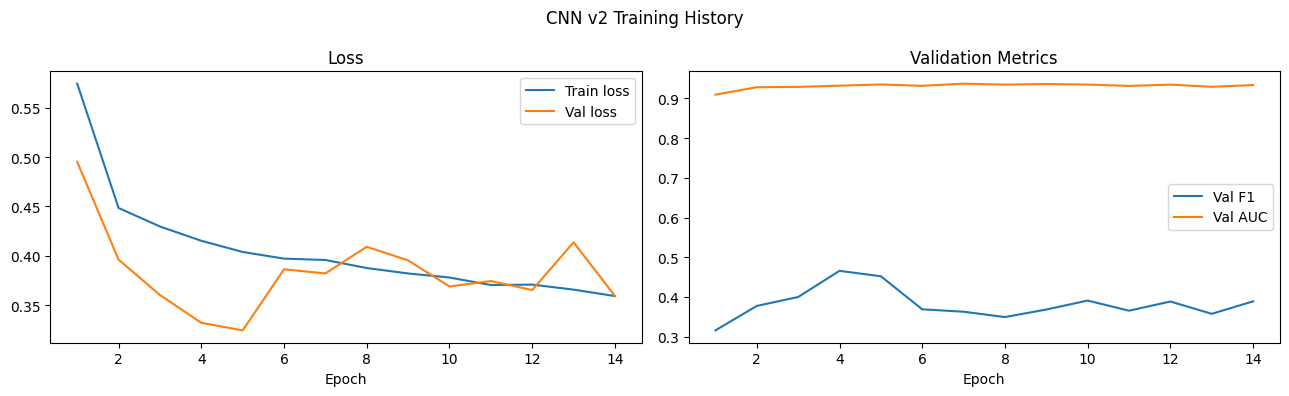

In [15]:
hist_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(hist_df['epoch'], hist_df['train_loss'], label='Train loss')
axes[0].plot(hist_df['epoch'], hist_df['loss'],       label='Val loss')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(hist_df['epoch'], hist_df['f1'],  label='Val F1')
axes[1].plot(hist_df['epoch'], hist_df['auc'], label='Val AUC')
axes[1].set_title('Validation Metrics'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.suptitle('CNN v2 Training History'); plt.tight_layout(); plt.show()

## 5. Threshold Calibration
Sweep thresholds on the **validation set**, pick the one maximising F1,
then apply to **test set** — no test data used for selection.

In [16]:
best_model = CNN1D(N_FEATURES, best_params['n_filters'], best_params['kernel_size'],
                   best_params['n_conv_layers'], best_params['dropout']).to(DEVICE)
best_model.load_state_dict(torch.load(CHECKPOINT_DIR / 'best_model_v2.pt', map_location=DEVICE))

def get_probs(model, loader, device):
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for X, y in loader:
            all_logits.append(model(X.to(device)).cpu())
            all_labels.append(y)
    logits = torch.cat(all_logits).numpy()
    labels = torch.cat(all_labels).numpy().astype(int)
    return labels, 1 / (1 + np.exp(-logits))

val_labels,  val_probs  = get_probs(best_model, val_loader_f,  DEVICE)
test_labels, test_probs = get_probs(best_model, test_loader_f, DEVICE)

Best threshold (val F1-optimal) : 0.77
Val F1 at best threshold         : 0.5961


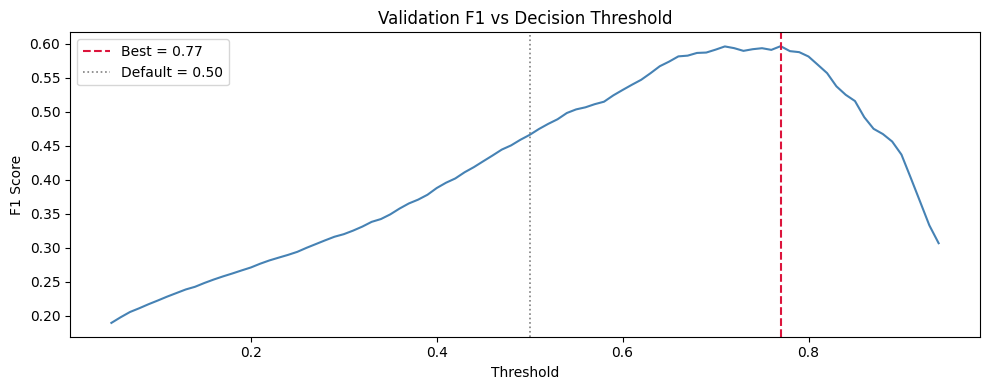

In [17]:
thresholds = np.arange(0.05, 0.95, 0.01)
val_f1s = [
    f1_score(val_labels, (val_probs >= t).astype(int), zero_division=0)
    for t in thresholds
]
best_threshold = float(thresholds[np.argmax(val_f1s)])
print(f'Best threshold (val F1-optimal) : {best_threshold:.2f}')
print(f'Val F1 at best threshold         : {max(val_f1s):.4f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, val_f1s, color='steelblue', lw=1.5)
ax.axvline(best_threshold, color='crimson', ls='--', lw=1.5, label=f'Best = {best_threshold:.2f}')
ax.axvline(0.5, color='gray', ls=':', lw=1.2, label='Default = 0.50')
ax.set_title('Validation F1 vs Decision Threshold')
ax.set_xlabel('Threshold'); ax.set_ylabel('F1 Score'); ax.legend()
plt.tight_layout(); plt.show()

## 6. Final Evaluation

Metrics at calibrated threshold=0.77:
                f1  precision  recall
Validation  0.5961     0.6472  0.5525
Test        0.4157     0.3397  0.5354


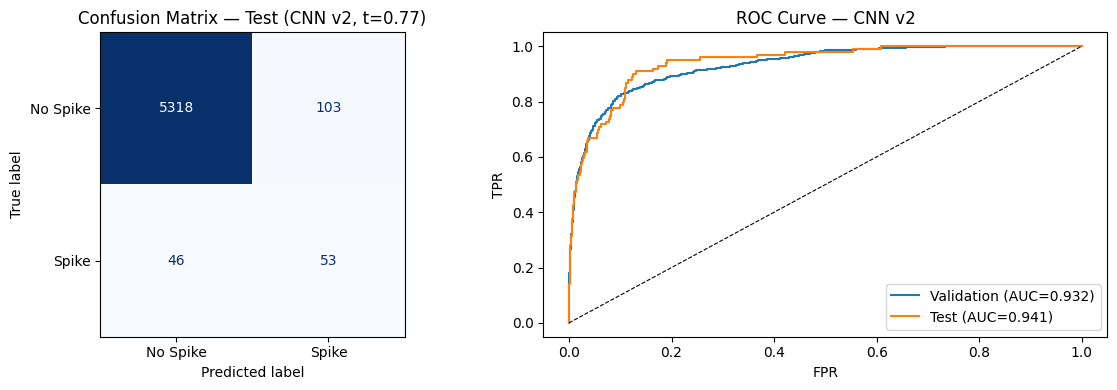


Test Classification Report (threshold=0.77):
              precision    recall  f1-score   support

    No Spike       0.99      0.98      0.99      5421
       Spike       0.34      0.54      0.42        99

    accuracy                           0.97      5520
   macro avg       0.67      0.76      0.70      5520
weighted avg       0.98      0.97      0.98      5520



In [18]:
val_preds_cal  = (val_probs  >= best_threshold).astype(int)
test_preds_cal = (test_probs >= best_threshold).astype(int)

val_metrics_cal = {
    'f1':        f1_score(val_labels,  val_preds_cal,  zero_division=0),
    'precision': precision_score(val_labels,  val_preds_cal,  zero_division=0),
    'recall':    recall_score(val_labels,  val_preds_cal,  zero_division=0),
}
test_metrics_cal = {
    'f1':        f1_score(test_labels, test_preds_cal, zero_division=0),
    'precision': precision_score(test_labels, test_preds_cal, zero_division=0),
    'recall':    recall_score(test_labels, test_preds_cal, zero_division=0),
}

print(f'Metrics at calibrated threshold={best_threshold:.2f}:')
print(pd.DataFrame([val_metrics_cal, test_metrics_cal], index=['Validation', 'Test']).round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(
    test_labels, test_preds_cal, ax=axes[0],
    display_labels=['No Spike', 'Spike'], cmap='Blues', colorbar=False
)
axes[0].set_title(f'Confusion Matrix \u2014 Test (CNN v2, t={best_threshold:.2f})')

for labels, probs, name in [(val_labels, val_probs, 'Validation'),
                             (test_labels, test_probs, 'Test')]:
    fpr, tpr, _ = roc_curve(labels, probs)
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc(fpr, tpr):.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=0.8)
axes[1].set_title('ROC Curve \u2014 CNN v2')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR'); axes[1].legend()
plt.tight_layout(); plt.show()

print(f'\nTest Classification Report (threshold={best_threshold:.2f}):')
print(classification_report(test_labels, test_preds_cal, target_names=['No Spike', 'Spike']))

## 7. Summary

In [19]:
print('=' * 55)
print('CNN v2 FINAL RESULTS')
print('=' * 55)
print(f'Best hyperparameters : {best_params}')
print(f'Calibrated threshold : {best_threshold:.2f}  (tuned on validation set)')

print(f'\nValidation set (threshold={best_threshold:.2f}):')
for k, v in val_metrics_cal.items(): print(f'  {k:12s}: {v:.4f}')

print(f'\nTest set (threshold={best_threshold:.2f})  <- primary result:')
for k, v in test_metrics_cal.items(): print(f'  {k:12s}: {v:.4f}')

print(f'\nNote: AUC reported in ROC curve above')
print(f'Checkpoints saved to: {CHECKPOINT_DIR}')

CNN v2 FINAL RESULTS
Best hyperparameters : {'lookback': 24, 'n_filters': 64, 'kernel_size': 3, 'n_conv_layers': 2, 'dropout': 0.3, 'lr': 0.001, 'batch_size': 64, 'pw_scale': 0.5}
Calibrated threshold : 0.77  (tuned on validation set)

Validation set (threshold=0.77):
  f1          : 0.5961
  precision   : 0.6472
  recall      : 0.5525

Test set (threshold=0.77)  <- primary result:
  f1          : 0.4157
  precision   : 0.3397
  recall      : 0.5354

Note: AUC reported in ROC curve above
Checkpoints saved to: /content/drive/MyDrive/EnergySpike/CNN model/checkpoints_v2
